# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

## Transaction Costs and Slippage

In the previous notebook, you learned how to analyse the performance of your trading strategy.

In this notebook, you will learn how to properly account for commissions, slippages, taxes and transaction costs before taking your strategy live. 

1. [Read the Data](#read) 
2. [Calculate Brokerage Costs](#cost)
3. [Slippage Modelling](#slippage)
4. [Strategy Returns with Transaction Cost and Slippage](#tc)
5. [Total PnL after Brokerage, Transaction and Slippage](#pnl)

## Import the Libraries 

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# For plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

<a id='read'></a> 
## Read the Data 

We have saved the close price data and trade signals generated according to the head and shoulders pattern in the CSV file named `signals_hs_spy_1993_2018.csv`. We will also need the trade details saved in `trades_hs_spy_1993_2018.csv`. You can read these files using the `pandas.read_csv()` method.  

In [2]:
# Read price data and trade signals
data = pd.read_csv('../data_modules/signals_hs_spy_1993_2018.csv', index_col=0)

# Set index to datetime
data.index = pd.to_datetime(data.index)

# Read the trade details
trades = pd.read_csv('../data_modules/trades_hs_spy_1993_2018.csv', index_col=0)

<a id='cost'></a> 
## Calculate Brokerage Costs

A brokerage fee is a fee or commission a broker charges to execute transactions. These can include a charge for additional services, exchange-mandated costs and any government tax that gets imposed on the financial transaction.

Here, we have taken the brokerage fee as 0.03% of traded value and taxes as 0.02% of traded value. However, you should always check with your broker for the exact charges, as they are not constant everywhere. 

In [3]:
# Brokerage fee
brokerage = 0.03/100

# Taxes
tax = 0.02/100

# Total brokerage cost
broker_cost = brokerage + tax
broker_cost

0.0005

The brokerage cost works out to be 0.05%.
<a id='slippage'></a> 
## Slippage Modelling
Slippage is the difference between the expected price of a trade and the price at which the trade is executed. It is not easy to estimate slippage since in a way it is like predicting market behaviour. So, we estimate the slippage by finding the difference between the last traded price and the worst possible execution price. 

Steps to model slippage:

1. Read minute level data
2. Extract last five minutes candles for each day
3. Calculate slippage for buy and sell orders

### Read minute level data 

In [4]:
# Read 1 minute level data 
stock_data_1m = pd.read_csv("../data_modules/hs_spy_1m_5days.csv", index_col=0)

# Set the index to datetime
stock_data_1m.index = pd.to_datetime(stock_data_1m.index)

# Display the last five rows
stock_data_1m.tail()

,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2022-10-12 15:56:00-04:00,357.130005,357.140015,356.799988,356.940186,356.940186,1297637
2022-10-12 15:57:00-04:00,356.940002,357.269989,356.820007,356.980011,356.980011,622406
2022-10-12 15:58:00-04:00,356.989990,357.049988,356.730011,356.795013,356.795013,689629
2022-10-12 15:59:00-04:00,356.799988,356.989990,356.500000,356.549988,356.549988,1874663
2022-10-12 16:00:00-04:00,356.559998,356.559998,356.559998,356.559998,356.559998,0


### Extract last 5 minutes candles for each day

As liquidity is high at the end of the trading day, we will use only the last five minutes candles to estimate slippage.

To do that, we will use the `groupby` method of pandas. the syntax is as follows: 

Syntax:
```python
DataFrame.groupby(by, axis=0)
```
1. **by:** Used to determine the groups for the groupby. 
2. **axis:** Split along rows (0) or columns (1). Default is 0. 

In [5]:
# Reset the index
stock_data_1m.reset_index(inplace=True)

# Extract last 5 candles for each day
stock_data_1m = stock_data_1m.groupby([stock_data_1m['Datetime'].dt.date]).tail(5)

# Display the last five rows
stock_data_1m.tail()

,Datetime,Open,High,Low,Close,Adj Close,Volume
1943,2022-10-12 15:56:00-04:00,357.130005,357.140015,356.799988,356.940186,356.940186,1297637
1944,2022-10-12 15:57:00-04:00,356.940002,357.269989,356.820007,356.980011,356.980011,622406
1945,2022-10-12 15:58:00-04:00,356.989990,357.049988,356.730011,356.795013,356.795013,689629
1946,2022-10-12 15:59:00-04:00,356.799988,356.989990,356.500000,356.549988,356.549988,1874663
1947,2022-10-12 16:00:00-04:00,356.559998,356.559998,356.559998,356.559998,356.559998,0


### Calculate slippage for buy and sell orders

1. For a buy order, the worst execution price would occur by buying at the high of the bar. So slippage would be: 

        Worst execution price (high price) - Last traded price (close price)

2. For a sell order, it would occur by selling at the low of the bar. So slippage would be:  

        Last traded price (close price) - Worst execution price (low price)

In this strategy, orders are executed at the close price. Therefore, we will use slippage in terms of the percentage of closing prices.

In [6]:
# Calculate slippage for buy orders
stock_data_1m['slippage_buy_order'] = (
    stock_data_1m['High'] - stock_data_1m['Close']) / stock_data_1m['Close']

# Calculate slippage for sell orders
stock_data_1m['slippage_sell_order'] = (
    stock_data_1m['Close'] - stock_data_1m['Low']) / stock_data_1m['Close']

# Mean of the slippage for buy and sell orders for each day
stock_data_1m = stock_data_1m.groupby([stock_data_1m['Datetime'].dt.date]).median()

# Display the dataframe
stock_data_1m.head()

,Datetime,Open,High,Low,Close,Adj Close,Volume,slippage_buy_order,slippage_sell_order
Datetime,,,,,,,,,
2022-10-06,2022-10-06 15:57:00-04:00,373.470001,373.600006,373.220001,373.378906,373.378906,643243.0,0.000777,0.000643
2022-10-07,2022-10-07 15:57:00-04:00,363.109985,363.190002,362.739990,363.109985,363.109985,1229653.0,0.000165,0.000937
2022-10-10,2022-10-10 15:57:00-04:00,360.630005,360.649994,360.220001,360.250000,360.250000,382813.0,0.001110,0.000139
2022-10-11,2022-10-11 15:57:00-04:00,357.829987,358.160004,357.700012,357.839996,357.839996,565418.0,0.000419,0.000642
2022-10-12,2022-10-12 15:58:00-04:00,356.940002,357.049988,356.730011,356.795013,356.795013,689629.0,0.000715,0.000182


Finally, we will find the maximum possible slippage and use that figure in our analysis. 

In [7]:
# Maximum slippage for the buy and sell orders
slippage_cost = stock_data_1m[[
    'slippage_buy_order', 'slippage_sell_order']].max()

# Mean of the max slippage cost for buy and sell orders
slippage_cost = slippage_cost.mean()

# Print estimated slippage
print('Estimated slippage: %.4f' % slippage_cost)

Estimated slippage: 0.0010


The estimated slippage works out to be 0.10% of the close price. 
<a id='tc'></a> 
## Strategy Returns after Transaction Cost and Slippage

First, we estimate the trading cost and slippage. We have taken the transaction cost of 0.001 per dollar worth of shares purchased or sold. Feel free to change the transaction cost to a value that suits your local markets and broker. Add the estimated transaction and slippage cost. 

In [8]:
# Calculate strategy returns
data['strategy_ret'] = data.signal.shift(1) * data.Close.pct_change()

# Transaction cost
transaction_cost = 0.0001

# Calculate total cost
total_charges = transaction_cost + slippage_cost + broker_cost 

# Display total cost
print('Total Charges: %.4f' % total_charges)

Total Charges: 0.0016


Next, we determine if there is a change in the position. This can be done by subtracting the trading signal of the current day from that of the previous day. 

Then multiply the change in the position with the total cost and deduct from daily strategy returns.

In [9]:
# Calculate the trading cost when you square off the position
trading_cost = (total_charges * np.abs(data.signal -
                                       data.signal.shift(1)))

# Calculate net strategy returns
data['strategy_returns_minus_cost'] = data['strategy_ret'] - trading_cost

<a id='cum_returns'></a> 
### Plot cumulative strategy returns

You will plot the cumulative strategy returns using the Matplotlib library.

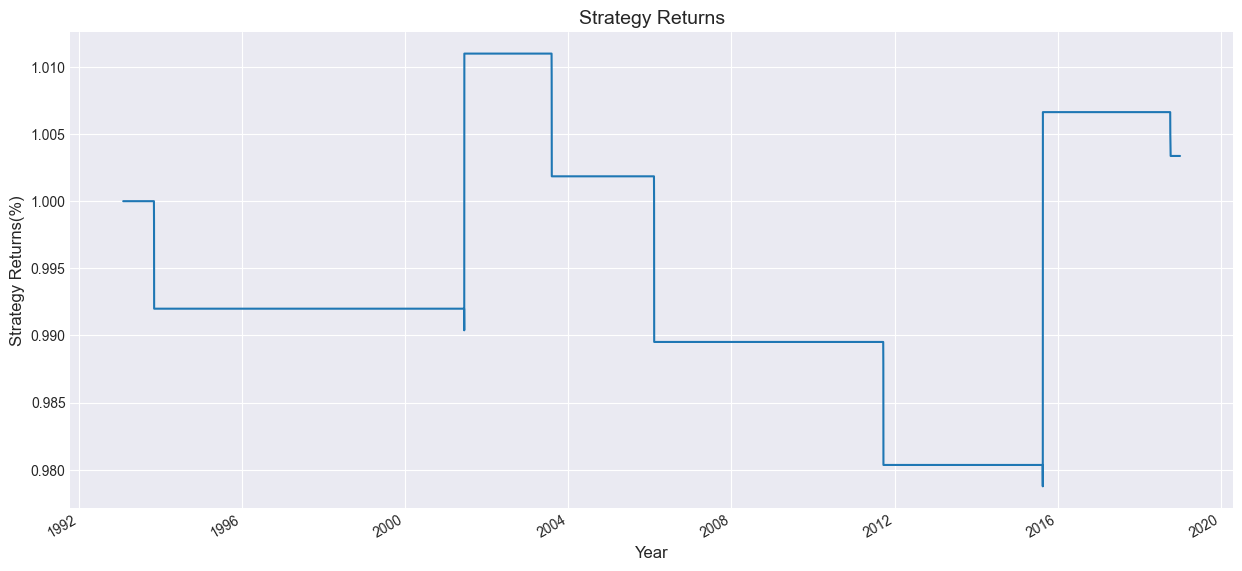

In [10]:
# Calculate and plot cumulative strategy returns
cum_strategy_returns = (data['strategy_returns_minus_cost']+1).cumprod()
cum_strategy_returns.plot(figsize=(15, 7))

# Add title and labels
plt.title('Strategy Returns', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Strategy Returns(%)', fontsize=12)

# Display the chart
plt.show()

Previously we saw that the strategy had a cumulative return of 1.126x. However, we can observe that after incorporating the transaction costs and slippage, the cumulative return of the strategy falls to approximately 1.004x. 

Let's compute the total PnL and the overall cost to better comprehend this. Then, let's compare these values. We imported the required data which is stored in the dataframe `trades`. 

In [11]:
# Compute total PnL
total_pnl = trades['PnL'].sum()
print('Total PnL: %.4f' % total_pnl)

Total PnL: 14.0500


In [12]:
# Compute costs
trades['cost'] = ((trades['entry_price'] + trades['exit_price'])* total_charges)

# Compute total costs
total_costs = trades['cost'].sum()
print('Total Costs: %.4f' % total_costs)

Total Costs: 3.1753


## Conclusion

We can observe that the total PnL is greater than the total cost. This means that the total PnL generated by this strategy was enough to cover the costs associated with live trading it.

In the upcoming sections, we will learn about other patterns, such as the inverse head and shoulders pattern. 